# TCN Punch Classification Training (Baseline)

Train a Temporal Convolutional Network as a baseline comparison against ST-GCN.

**Input:** (T=48, 9 joints, 3 XYZ) flattened to (T=48, 27) — joint relationships not explicitly modeled
**Output:** Class probability distribution over 4 punch types
**Architecture:** TCN with dilated 1D convolutions
**Validation:** Subject-level split (default: subjects 1-3 train, subject 4 test) with optional 4-fold cross-validation

This notebook is structurally identical to `train_stgcn.ipynb` — only the model architecture differs.

In [2]:
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Configuration

Same hyperparameters as ST-GCN for fair comparison.

In [3]:
PROJECT_ROOT = Path("../../")

METADATA_DIR = PROJECT_ROOT / "data" / "metadata" / "no_hardware"
CLIPS_DIR = PROJECT_ROOT / "data" / "clips" / "no_hardware"
ANNOTATIONS_CSV = METADATA_DIR / "annotations.csv"
MODELS_DIR = PROJECT_ROOT / "models" / "tcn"
LOGS_DIR = PROJECT_ROOT / "logs" / "tensorboard"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

# Data parameters
T = 48
N_JOINTS = 9
N_CHANNELS = 3  # XYZ
N_FEATURES = N_JOINTS * N_CHANNELS  # 27 flattened features per frame
N_CLASSES = 5
CLASS_TO_IDX = {"cross": 0, "hook": 1, "jab": 2, "uppercut": 3, "no_punch": 4}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# Training hyperparameters (matching ST-GCN for fair comparison)
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 80
WEIGHT_DECAY = 1e-4

# Validation strategy
TEST_SUBJECT = "subject04"
RUN_CROSS_VALIDATION = True

# Tensorboard run name
RUN_NAME = f"tcn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

print(f"Run name: {RUN_NAME}")
print(f"Logs:     {LOGS_DIR / RUN_NAME}")
print(f"Models:   {MODELS_DIR}")

Run name: tcn_20260526_143816
Logs:     ../../logs/tensorboard/tcn_20260526_143816
Models:   ../../models/tcn


## Dataset Class

Same as ST-GCN dataset, but reshapes output to (T, N_FEATURES) for TCN input.

In [ ]:
class PunchDatasetTCN(Dataset):
    """PyTorch Dataset for TCN — flattens joint dimension into features."""
    
    def __init__(self, annotations_df: pd.DataFrame, clips_dir: Path, T: int, augment: bool = True):
        self.df = annotations_df.reset_index(drop=True)
        self.clips_dir = clips_dir
        self.T = T
        self.augment = augment
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_path = self.clips_dir / row["class"] / f"{row['clip_id']}.npy"
        clip = np.load(clip_path).astype(np.float32)  # (frames, 9, 3)
        
        clip = self._pad_or_truncate(clip)  # (T, 9, 3)
        
        # Flatten joints + xyz into features per frame: (T, 27)
        # Then transpose to (C=27, T) for Conv1d
        clip = clip.reshape(self.T, -1).transpose(1, 0)
        
        tensor = torch.from_numpy(clip)
        label = CLASS_TO_IDX[row["class"]]
        
        return tensor, label
    
    def _pad_or_truncate(self, clip: np.ndarray) -> np.ndarray:
        clip_len = clip.shape[0]
        if clip_len >= self.T:
            return clip[:self.T]
        
        if self.augment:
            offset = random.randint(0, self.T - clip_len)
            pre_pad = np.repeat(clip[:1], offset, axis=0)
            post_pad = np.repeat(clip[-1:], self.T - offset - clip_len, axis=0)
            return np.concatenate([pre_pad, clip, post_pad], axis=0)
        
        pad_amount = self.T - clip_len
        last_frame = clip[-1:].repeat(pad_amount, axis=0)
        return np.concatenate([clip, last_frame], axis=0)


    # Quick test
df_all = pd.read_csv(ANNOTATIONS_CSV)
test_ds = PunchDatasetTCN(df_all.head(2), CLIPS_DIR, T=T, augment=False)
sample_tensor, sample_label = test_ds[0]
print(f"Sample tensor shape: {sample_tensor.shape}  (expected: ({N_FEATURES}, {T}))")
print(f"Sample label: {sample_label} ({IDX_TO_CLASS[sample_label]})")

Sample tensor shape: torch.Size([27, 48])  (expected: (27, 48))
Sample label: 4 (no_punch)


## TCN Model

Dilated 1D convolutions across the time axis. Joints are flattened into channels — the model has no explicit knowledge of joint connectivity, which is the key distinction from ST-GCN.

**Architecture:**
- Multiple TCN blocks with exponentially increasing dilation
- Each block: dilated Conv1d → BatchNorm → ReLU → Dropout
- Residual connections
- Final: global average pooling → classification head

In [5]:
class TCNBlock(nn.Module):
    """Single TCN block: dilated Conv1d + BN + ReLU + Dropout + residual."""
    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int = 5, dilation: int = 1, dropout: float = 0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        
        # Residual projection if channels change
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        res = self.residual(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        x = self.relu(x + res)
        x = self.dropout(x)
        return x


class TCN(nn.Module):
    """Temporal Convolutional Network for punch classification."""
    def __init__(self, in_channels: int = N_FEATURES, n_classes: int = N_CLASSES,
                 channels: list = [64, 128, 256], kernel_size: int = 5, dropout: float = 0.2):
        super().__init__()
        
        self.data_bn = nn.BatchNorm1d(in_channels)
        
        layers = []
        prev_channels = in_channels
        for i, ch in enumerate(channels):
            dilation = 2 ** i  # 1, 2, 4
            layers.append(TCNBlock(prev_channels, ch, kernel_size, dilation, dropout))
            prev_channels = ch
        
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(prev_channels, n_classes)
    
    def forward(self, x):
        # x: (B, C, T)
        x = self.data_bn(x)
        x = self.tcn(x)
        x = x.mean(dim=2)  # Global avg pool over time → (B, C')
        x = self.fc(x)
        return x


# Sanity check
model = TCN().to(DEVICE)
sample_input = torch.randn(2, N_FEATURES, T).to(DEVICE)
sample_output = model(sample_input)
print(f"Model output shape: {sample_output.shape}  (expected: (2, {N_CLASSES}))")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([2, 5])  (expected: (2, 5))
Total parameters: 690,683


## Training Loop

Same as ST-GCN training loop, just with TCN model.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += inputs.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += inputs.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(train_df, test_df, run_name, epochs=EPOCHS):
    """Train one TCN model on the given split."""
    
    train_ds = PunchDatasetTCN(train_df, CLIPS_DIR, T=T, augment=True)
    test_ds = PunchDatasetTCN(test_df, CLIPS_DIR, T=T, augment=False)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    print(f"Train: {len(train_ds)} clips | Test: {len(test_ds)} clips")
    
    model = TCN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    writer = SummaryWriter(LOGS_DIR / run_name)
    
    best_test_acc = 0
    best_model_path = MODELS_DIR / f"{run_name}_best.pt"
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion)
        scheduler.step()
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/test", test_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/test", test_acc, epoch)
        writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), best_model_path)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
                  f"Test loss {test_loss:.4f} acc {test_acc:.3f} | "
                  f"Best {best_test_acc:.3f}")
    
    writer.close()
    print(f"\nBest test accuracy: {best_test_acc:.4f}")
    print(f"Best model saved to: {best_model_path}")
    
    return history, best_model_path, best_test_acc

In [7]:
df_all = pd.read_csv(ANNOTATIONS_CSV)

train_df = df_all[df_all["subject_id"] != TEST_SUBJECT].reset_index(drop=True)
test_df = df_all[df_all["subject_id"] == TEST_SUBJECT].reset_index(drop=True)

print(f"Train subjects: {sorted(train_df['subject_id'].unique())}")
print(f"Test subject:   {TEST_SUBJECT}")
print()

history, best_model_path, best_acc = train_model(train_df, test_df, RUN_NAME)

Train subjects: ['subject01', 'subject02', 'subject03']
Test subject:   subject04

Train: 892 clips | Test: 345 clips
Epoch   1/80 | Train loss 0.5177 acc 0.823 | Test loss 1.8143 acc 0.420 | Best 0.420
Epoch   5/80 | Train loss 0.0361 acc 0.990 | Test loss 0.2062 acc 0.942 | Best 0.942
Epoch  10/80 | Train loss 0.1183 acc 0.970 | Test loss 0.6489 acc 0.817 | Best 0.942
Epoch  15/80 | Train loss 0.0293 acc 0.990 | Test loss 0.2959 acc 0.896 | Best 0.965
Epoch  20/80 | Train loss 0.0030 acc 0.999 | Test loss 0.1558 acc 0.942 | Best 0.965
Epoch  25/80 | Train loss 0.0062 acc 0.997 | Test loss 0.1781 acc 0.942 | Best 0.971
Epoch  30/80 | Train loss 0.0098 acc 0.999 | Test loss 0.1182 acc 0.957 | Best 0.971
Epoch  35/80 | Train loss 0.0049 acc 0.999 | Test loss 0.1095 acc 0.977 | Best 0.977
Epoch  40/80 | Train loss 0.0015 acc 0.999 | Test loss 0.0972 acc 0.980 | Best 0.980
Epoch  45/80 | Train loss 0.0050 acc 0.998 | Test loss 0.1164 acc 0.971 | Best 0.980
Epoch  50/80 | Train loss 0.0211

## Training Visualizations

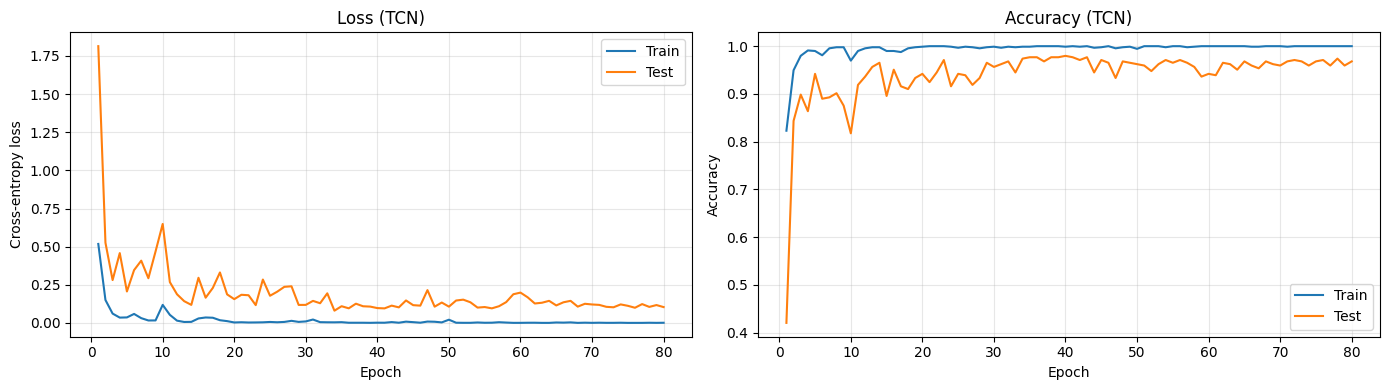

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["test_loss"], label="Test")
axes[0].set_title("Loss (TCN)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["test_acc"], label="Test")
axes[1].set_title("Accuracy (TCN)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Confusion Matrix

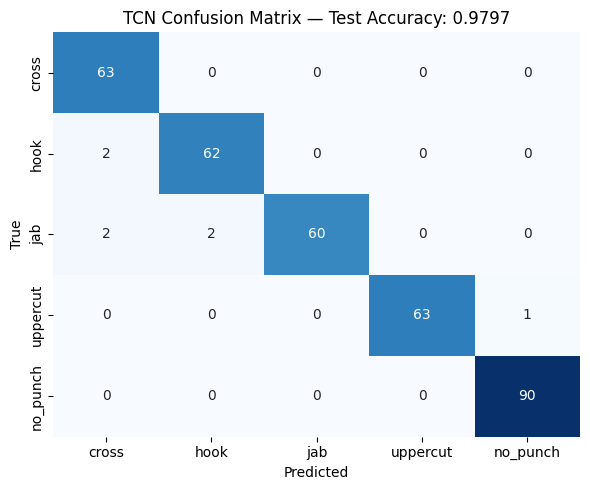


Per-class accuracy:
  cross: 1.000  (63/63)
  hook: 0.969  (62/64)
  jab: 0.938  (60/64)
  uppercut: 0.984  (63/64)
  no_punch: 1.000  (90/90)


In [9]:
model = TCN().to(DEVICE)
model.load_state_dict(torch.load(best_model_path))

test_ds = PunchDatasetTCN(test_df, CLIPS_DIR, T=T)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
criterion = nn.CrossEntropyLoss()

_, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion)

class_names = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]
cm = confusion_matrix(all_labels, all_preds, labels=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"TCN Confusion Matrix — Test Accuracy: {test_acc:.4f}")
plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
for i, name in enumerate(class_names):
    class_total = (np.array(all_labels) == i).sum()
    class_correct = ((np.array(all_labels) == i) & (np.array(all_preds) == i)).sum()
    if class_total > 0:
        print(f"  {name}: {class_correct/class_total:.3f}  ({class_correct}/{class_total})")

## 4-Fold Cross-Validation (Optional)

Set `RUN_CROSS_VALIDATION = True` in the configuration cell to enable.

Running 4-fold cross-validation across subjects: ['subject01', 'subject02', 'subject03', 'subject04']

FOLD 1/4 — Test subject: subject01
Train: 939 clips | Test: 298 clips
Epoch   1/80 | Train loss 0.5150 acc 0.831 | Test loss 2.7811 acc 0.352 | Best 0.352
Epoch   5/80 | Train loss 0.0788 acc 0.971 | Test loss 0.5028 acc 0.829 | Best 0.940
Epoch  10/80 | Train loss 0.0134 acc 0.996 | Test loss 0.2500 acc 0.930 | Best 0.970
Epoch  15/80 | Train loss 0.0198 acc 0.994 | Test loss 0.4183 acc 0.866 | Best 0.970
Epoch  20/80 | Train loss 0.0030 acc 0.999 | Test loss 0.1916 acc 0.953 | Best 0.977
Epoch  25/80 | Train loss 0.0188 acc 0.994 | Test loss 0.4151 acc 0.923 | Best 0.977
Epoch  30/80 | Train loss 0.0014 acc 1.000 | Test loss 0.1438 acc 0.943 | Best 0.977
Epoch  35/80 | Train loss 0.0278 acc 0.995 | Test loss 0.1950 acc 0.946 | Best 0.977
Epoch  40/80 | Train loss 0.0023 acc 1.000 | Test loss 0.2422 acc 0.956 | Best 0.977
Epoch  45/80 | Train loss 0.0022 acc 0.999 | Test loss 0.1684 

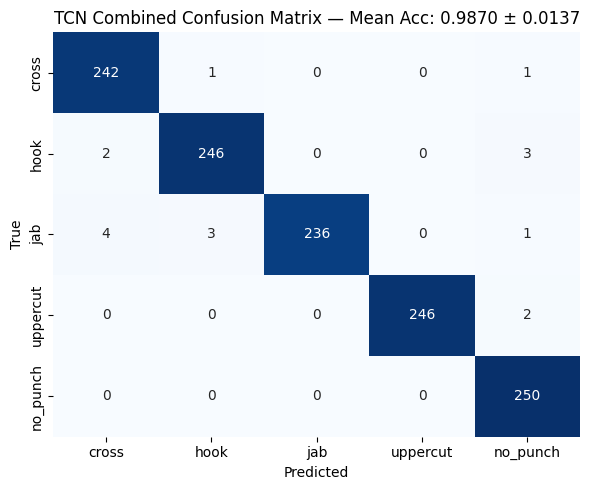

In [10]:
if RUN_CROSS_VALIDATION:
    subjects = sorted(df_all["subject_id"].unique())
    print(f"Running {len(subjects)}-fold cross-validation across subjects: {subjects}\n")
    
    fold_results = []
    
    for fold_idx, test_subj in enumerate(subjects):
        print("=" * 60)
        print(f"FOLD {fold_idx + 1}/{len(subjects)} — Test subject: {test_subj}")
        print("=" * 60)
        
        train_df_fold = df_all[df_all["subject_id"] != test_subj].reset_index(drop=True)
        test_df_fold = df_all[df_all["subject_id"] == test_subj].reset_index(drop=True)
        
        fold_run_name = f"{RUN_NAME}_fold{fold_idx+1}_{test_subj}"
        history_f, model_path_f, best_acc_f = train_model(
            train_df_fold, test_df_fold, fold_run_name, epochs=EPOCHS
        )
        
        m = TCN().to(DEVICE)
        m.load_state_dict(torch.load(model_path_f))
        test_loader_f = DataLoader(
            PunchDatasetTCN(test_df_fold, CLIPS_DIR, T=T),
            batch_size=BATCH_SIZE, shuffle=False
        )
        _, acc_f, preds_f, labels_f = evaluate(m, test_loader_f, nn.CrossEntropyLoss())
        cm_f = confusion_matrix(labels_f, preds_f, labels=list(range(N_CLASSES)))
        
        fold_results.append({
            "fold": fold_idx + 1,
            "test_subject": test_subj,
            "best_acc": best_acc_f,
            "confusion_matrix": cm_f,
        })
    
    # Aggregate
    accs = [r["best_acc"] for r in fold_results]
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    
    print("\n" + "=" * 60)
    print("TCN CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    for r in fold_results:
        print(f"  Fold {r['fold']} ({r['test_subject']}): {r['best_acc']:.4f}")
    print(f"\n  Mean: {mean_acc:.4f} ± {std_acc:.4f}")
    
    cm_combined = np.sum([r["confusion_matrix"] for r in fold_results], axis=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_combined, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"TCN Combined Confusion Matrix — Mean Acc: {mean_acc:.4f} ± {std_acc:.4f}")
    plt.tight_layout()
    plt.show()
else:
    print("Cross-validation skipped. Set RUN_CROSS_VALIDATION = True in Cell 4 to enable.")

## Summary

In [11]:
print("=" * 60)
print("TCN BASELINE TRAINING SUMMARY")
print("=" * 60)
print(f"Run name:           {RUN_NAME}")
print(f"Model architecture: TCN ({sum(p.numel() for p in TCN().parameters()):,} params)")
print(f"Total clips:        {len(df_all)}")
print(f"Classes:            {sorted(df_all['class'].unique())}")
print(f"Subjects:           {sorted(df_all['subject_id'].unique())}")
print(f"T window:           {T}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Learning rate:      {LEARNING_RATE}")
print(f"Epochs:             {EPOCHS}")
print(f"\nSingle-split (test={TEST_SUBJECT}): {best_acc:.4f}")

if RUN_CROSS_VALIDATION:
    print(f"4-fold CV mean:     {mean_acc:.4f} ± {std_acc:.4f}")
print("=" * 60)

TCN BASELINE TRAINING SUMMARY
Run name:           tcn_20260526_143816
Model architecture: TCN (690,683 params)
Total clips:        1237
Classes:            ['cross', 'hook', 'jab', 'no_punch', 'uppercut']
Subjects:           ['subject01', 'subject02', 'subject03', 'subject04']
T window:           48
Batch size:         32
Learning rate:      0.001
Epochs:             80

Single-split (test=subject04): 0.9797
4-fold CV mean:     0.9870 ± 0.0137
